# Pacotes e dados experimentais

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
from random import randint

data = pd.read_csv("delta_S_p2_rev_comp.csv", header=None).rename(columns={0:"T(K)",2:"DS(J/kgK)"})
T_exp  = data["T(K)"].values
DS_exp = data["DS(J/kgK)"].values

# Funções e constantes

In [26]:
##########################################################
# Constantes
##########################################################
R = 8.314 # J/molK
k_B = 1.380649e-23
mu_B = 9.2740100783e-24
M = 0.540273 # kg/mol

P_init = 101325 # pressão inicial em bar
P_fin = 200e6 # pressão final em bar
##########################################################
# Funções auxiliares
##########################################################
def T_model(m, delta_0, delta_V, P, g, T0):
    P_linha = (((delta_V) * P)) / 4
    gamma = (delta_0 + P_linha/k_B) / (T0)
    numerator = 2 * (m - gamma)
    denominator = np.log((m + 1) / (g**2 * (1 - m)))
    return T0 * (numerator / denominator)

def S_C(n_hs):
    return -R/M*(n_hs*np.log(n_hs) + (1-n_hs)*np.log(1-n_hs))

def S_S(T, g_J, J, B):
    x = (g_J * mu_B * J * B) / (k_B * T)
    num = np.sinh((2 * J + 1) * x / (2 * J))
    den = np.sinh(x / (2 * J))
    Z = num / den
    coeff = (2 * J + 1) / (2 * J)
    B_J = (coeff / np.tanh(coeff * x)) - (1 / (2 * J * np.tanh(x / (2 * J))))
    return R/M * (np.log(Z) + x * B_J)

def S_O(limite_soma, T, frequencias_cm):
    hbar = 1.054571817e-34
    c = 1
    beta = 1/(k_B*T)
    soma = 0.0
    for omega_cm in frequencias_cm:
        omega = 2*np.pi*c*omega_cm
        x = beta*hbar*omega
        if x == 0: 
            continue
        termo_log = -np.log(1 - np.exp(-x))
        termo_fracao = x/(np.exp(x) - 1)
        soma += termo_log + termo_fracao
    return R/M * soma
##########################################################
# Cálculo de ΔS e componentes no grid pedido (T_common)
##########################################################
def calc_deltaS_components(params, fixed, T_common, P_amb=P_init, P_high=P_fin,
                           freq_HS=frequencias_HS, freq_LS=frequencias_LS):
    # Usa valores fixos + ajustáveis
    T0      = params.get("T0",     fixed["T0"])
    g       = params.get("g",      fixed["g"])
    Delta0  = params.get("Delta0", fixed["Delta0"])
    delta_V = params.get("deltaV", fixed["deltaV"])

    # Varredura em m -> gera T(m) para P_init e P_fin
    m_vals = np.linspace(-0.999, 0.999, 10000)
    Temp_amb  = T_model(m_vals, Delta0, delta_V, P_amb,  g, T0)
    Temp_high = T_model(m_vals, Delta0, delta_V, P_high, g, T0)
    n_hs_vals = (m_vals+1)/2

    # Interpolar fração HS para T_common
    n_hs_amb  = np.interp(T_common, Temp_amb,  n_hs_vals)
    n_hs_high = np.interp(T_common, Temp_high, n_hs_vals)

    # (1) Configuracional
    delta_S_Config = -(S_C(n_hs_high) - S_C(n_hs_amb))

    # (2) Spin
    # Note que aqui nem entrou a parte de LS porque ela vai zerar de qualquer maneira já que nesse caso S = 0.
    # Mas caso não fosse 0, a contribuição existiria.
    S_S_amb  = n_hs_amb  * S_S(T_common, 2, 2, 0.01)
    S_S_high = n_hs_high * S_S(T_common, 2, 2, 0.01)
    delta_S_Spin = -(S_S_high - S_S_amb)

    # (3) Óptica
    freq_HS=list(frequencias_HS)
    freq_LS=list(frequencias_LS)
    S_O_HS = np.array([S_O(len(freq_HS), T, freq_HS) for T in T_common])
    S_O_LS = np.array([S_O(len(freq_LS), T, freq_LS) for T in T_common])
    S_O_high = n_hs_high*S_O_HS + (1-n_hs_high)*S_O_LS
    S_O_amb  = n_hs_amb *S_O_HS + (1-n_hs_amb )*S_O_LS
    delta_S_O = -(S_O_high - S_O_amb)

    delta_S_total = delta_S_Config + delta_S_Spin + delta_S_O
    return delta_S_total, delta_S_Config, delta_S_Spin, delta_S_O

##########################################################
# Alinhar dados ao grid comum e limitar intervalo de fit
##########################################################
def align_to_common_grid(T_exp, DS_exp, T_range=None, n_points=None):
    """Cria T_common igualmente espaçado dentro de T_range
       e interpola DS_exp para T_common.
    """
    # Limpeza, ordenação e máscara de intervalo
    T_exp = np.asarray(T_exp)
    DS_exp = np.asarray(DS_exp)
    # ordenar
    order = np.argsort(T_exp)
    T_exp = T_exp[order]
    DS_exp = DS_exp[order]
    # remover temperaturas duplicadas (mantém a média do DS nelas)
    T_unique, idxs = np.unique(T_exp, return_index=True)
    if len(T_unique) != len(T_exp):
        # média por temperatura
        df_tmp = pd.DataFrame({"T":T_exp, "DS":DS_exp}).groupby("T", as_index=False).mean()
        T_exp = df_tmp["T"].values
        DS_exp = df_tmp["DS"].values

    # intervalo
    if T_range is not None:
        tmin, tmax = T_range
        mask = (T_exp >= tmin) & (T_exp <= tmax)
        T_exp = T_exp[mask]
        DS_exp = DS_exp[mask]

    if n_points is None:
        n_points = len(T_exp)  # por padrão: mesmo nº de pontos do experimento no intervalo

    # criar grid comum e interpolar DS experimental nele
    T_common = np.linspace(T_exp.min(), T_exp.max(), 500)
    DS_exp_common = np.interp(T_common, T_exp, DS_exp)

    return T_common, DS_exp_common

##########################################################
# Rotina de ajuste (com intervalo e alinhamento)
##########################################################
def fit_params(T_exp, DS_exp, to_fit=("g","Delta0"),
               init_guess={"T0":310,"g":4000,"Delta0":2500,"deltaV":43e-30},
               bounds={"T0":(200,400),"g":(1000,10000),"Delta0":(1000,5000),"deltaV":(1e-31,1e-28)},
               T_range=(290,350), n_points=None,
               freq_HS=frequencias_HS, freq_LS=frequencias_LS,
               P_amb=101325, P_high=200e6):

    # Alinhar e interpolar experimental → T_common no intervalo escolhido
    T_common, DS_exp_common = align_to_common_grid(T_exp, DS_exp, T_range=T_range, n_points=n_points)

    fixed = init_guess.copy()
    var_names = list(to_fit)
    x0   = [init_guess[p] for p in var_names]
    bnds = np.array([bounds[p] for p in var_names]).T  # shape (2, n)

    def residuals(x):
        params = {p:val for p,val in zip(var_names, x)}
        DS_model,_,_,_ = calc_deltaS_components(params, fixed, T_common,
                                                P_amb=P_amb, P_high=P_high,
                                                freq_HS=frequencias_HS, freq_LS=frequencias_LS)
        return DS_model - DS_exp_common

    res = least_squares(residuals, x0, bounds=bnds)
    fitted = {p:val for p,val in zip(var_names, res.x)}

    # Curvas finais (total e componentes) já no T_common
    DS_fit, DS_conf, DS_spin, DS_opt = calc_deltaS_components(fitted, fixed, T_common,
                                                              P_amb=P_amb, P_high=P_high,
                                                              freq_HS=frequencias_HS, freq_LS=frequencias_LS)
    out = {
        "fitted_params": fitted,
        "result": res,
        "T_common": T_common,
        "DS_exp_common": DS_exp_common,
        "DS_fit": DS_fit,
        "DS_conf": DS_conf,
        "DS_spin": DS_spin,
        "DS_opt": DS_opt
    }
    return out

# Utilizando todas as frequências

Parâmetros ajustados: {'g': np.float64(1653.0386806436466), 'Delta0': np.float64(2290.6524871892775), 'T0': np.float64(245.0218486879072), 'deltaV': np.float64(3.002067634544646e-29)}


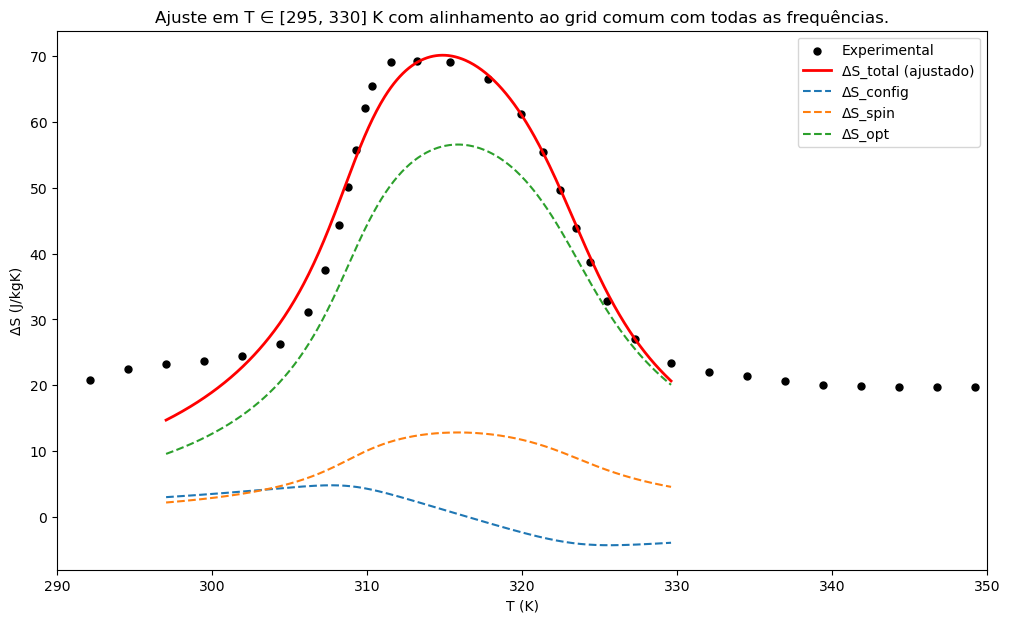

In [43]:
# Todas as frequencias foram utilizadas para o fit.
data_freq = pd.read_csv("modos_normais_oct.csv",decimal=",")
frequencias_HS = data_freq["HighSpin"]
frequencias_LS = data_freq["LowSpin"]
# Rodar ajuste no intervalo 290–350 K, usando mesmo nº de pontos do experimento nesse intervalo
T_min = 295
T_max = 330
out = fit_params(T_exp, DS_exp,
                 to_fit=("g","Delta0","T0","deltaV"),  # parametros a serem fitados
                 init_guess={"T0":250,"g":1000,"Delta0":2000,"deltaV":48e-30}, # chute inicial dos parametros
                 bounds={"T0":(100,650),"g":(800,20000),"Delta0":(1000,5000),"deltaV":(30e-30,50e-30)}, # limites em que os parametros vão variar
                 T_range=(T_min,T_max), n_points=None) # range da temperatura que sera feito o fit

print("Parâmetros ajustados:", out["fitted_params"])

# Plot: ajuste total + componentes no grid comum
plt.figure(figsize=(12,7))
plt.scatter(data["T(K)"].values, data["DS(J/kgK)"].values, label="Experimental", s=25,color='black')
plt.plot(out["T_common"], out["DS_fit"],  label="ΔS_total (ajustado)", linewidth=2,color='red')
plt.plot(out["T_common"], out["DS_conf"], label="ΔS_config", ls="--")
plt.plot(out["T_common"], out["DS_spin"], label="ΔS_spin",  ls="--")
plt.plot(out["T_common"], out["DS_opt"],  label="ΔS_opt",   ls="--")
plt.xlabel("T (K)")
plt.ylabel("ΔS (J/kgK)")
plt.title(f"Ajuste em T ∈ [{T_min}, {T_max}] K com alinhamento ao grid comum com todas as frequências.")
plt.legend()
plt.xlim(290,350)
plt.show()

Parâmetros ajustados: {'g': np.float64(1004.7539961475031), 'Delta0': np.float64(2132.330320045997), 'T0': np.float64(245.85614467681066), 'deltaV': np.float64(3.0038851075204216e-29)}


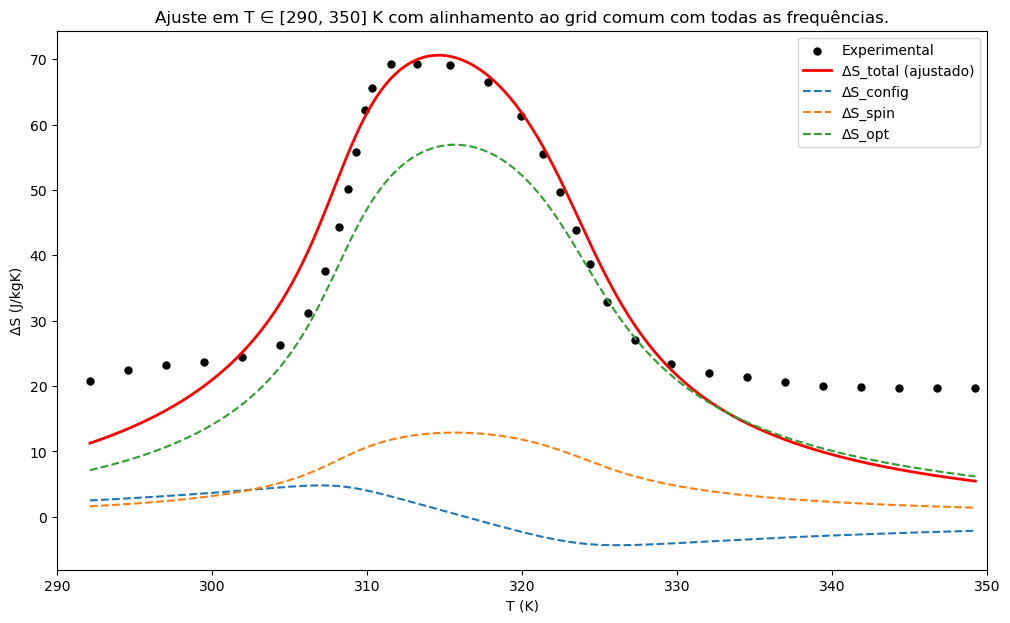

In [41]:
# Todas as frequencias foram utilizadas para o fit.
data_freq = pd.read_csv("modos_normais_oct.csv",decimal=",")
frequencias_HS = data_freq["HighSpin"]
frequencias_LS = data_freq["LowSpin"]
# Intervalo do ajuste
T_min = 290
T_max = 350
out = fit_params(T_exp, DS_exp,
                 to_fit=("g","Delta0","T0","deltaV"),  # parametros a serem fitados
                 init_guess={"T0":250,"g":1000,"Delta0":2000,"deltaV":48e-30}, # chute inicial dos parametros
                 bounds={"T0":(100,650),"g":(800,20000),"Delta0":(1000,5000),"deltaV":(30e-30,50e-30)}, # limites em que os parametros vão variar
                 T_range=(T_min,T_max), n_points=None) # range da temperatura que sera feito o fit

print("Parâmetros ajustados:", out["fitted_params"])

# Plot: ajuste total + componentes no grid comum
plt.figure(figsize=(12,7))
plt.scatter(data["T(K)"].values, data["DS(J/kgK)"].values, label="Experimental", s=25,color='black')
plt.plot(out["T_common"], out["DS_fit"],  label="ΔS_total (ajustado)", linewidth=2,color='red')
plt.plot(out["T_common"], out["DS_conf"], label="ΔS_config", ls="--")
plt.plot(out["T_common"], out["DS_spin"], label="ΔS_spin",  ls="--")
plt.plot(out["T_common"], out["DS_opt"],  label="ΔS_opt",   ls="--")
plt.xlabel("T (K)")
plt.ylabel("ΔS (J/kgK)")
plt.title(f"Ajuste em T ∈ [{T_min}, {T_max}] K com alinhamento ao grid comum com todas as frequências.")
plt.legend()
plt.xlim(290,350)
plt.show()

# Utilizando o histograma obtido (imagem abaixo) onde vamos considerar que existem 15 modos degenerados para o primeiro modo normal de ambos os histogramas, ou seja, $\omega^{HS} = 20$ cm$^{-1}$ e $\omega^{LS} = 74$ cm$^{-1}$.

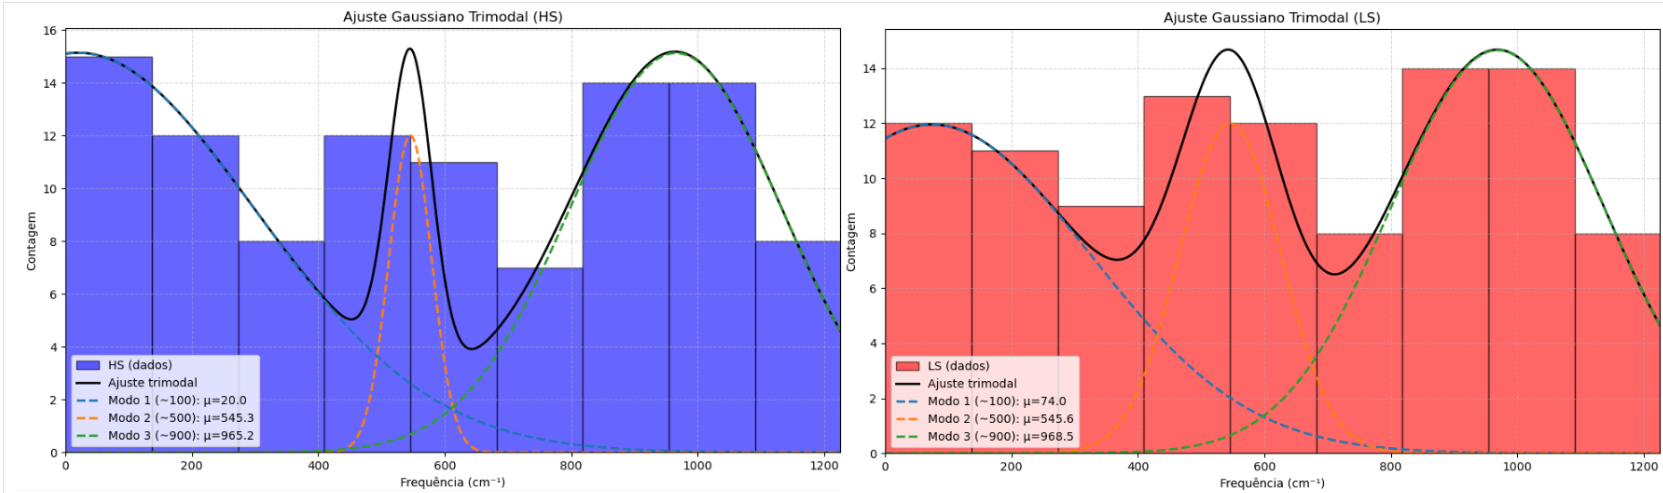

Parâmetros ajustados: {'g': np.float64(8356.325469864427), 'Delta0': np.float64(2271.9750736739147), 'T0': np.float64(50.50729679394214), 'deltaV': np.float64(7.950952423207253e-29)}


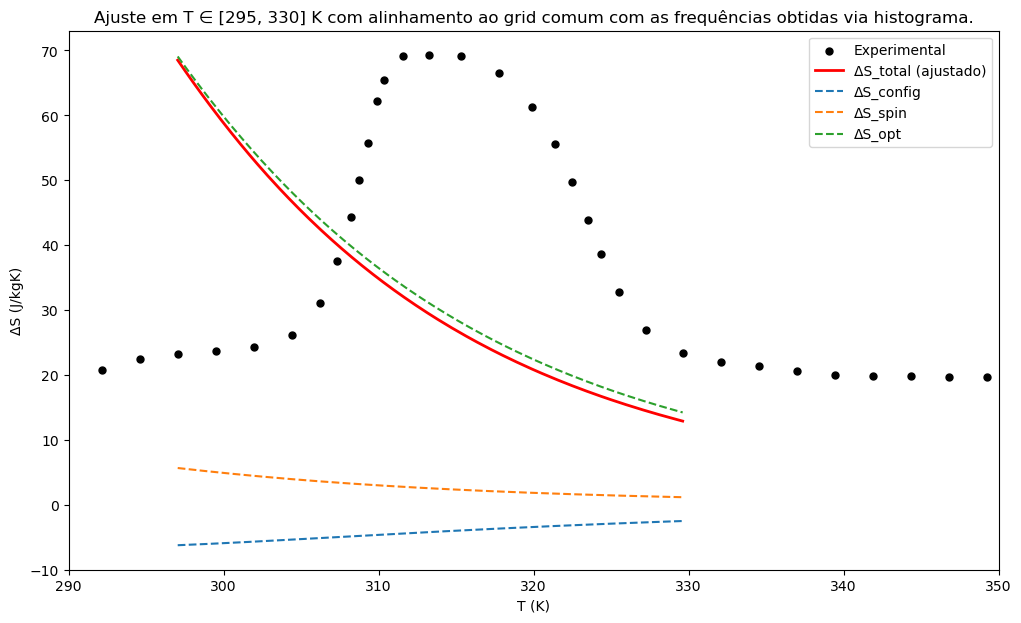

In [39]:
# Todas as frequencias foram utilizadas para o fit.
frequencias_HS = [20,20,20,20,20,
                  20,20,20,20,20,
                  20,20,20,20,20]
frequencias_LS = [74,74,74,74,74,
                  74,74,74,74,74,
                  74,74,74,74,74]
# Intervalo do ajuste
T_min = 295
T_max = 330
out = fit_params(T_exp, DS_exp,
                 to_fit=("g","Delta0","T0","deltaV"),  # parametros a serem fitados
                 init_guess={"T0":400,"g":864,"Delta0":3000,"deltaV":35e-30},
                 bounds={"T0":(50,650),"g":(500,20000),"Delta0":(1000,5000),"deltaV":(10e-30,90e-30)},
                 T_range=(T_min,T_max), n_points=None)

print("Parâmetros ajustados:", out["fitted_params"])

# Plot: ajuste total + componentes no grid comum
plt.figure(figsize=(12,7))
plt.scatter(data["T(K)"].values, data["DS(J/kgK)"].values, label="Experimental", s=25,color='black')
plt.plot(out["T_common"], out["DS_fit"],  label="ΔS_total (ajustado)", linewidth=2,color='red')
plt.plot(out["T_common"], out["DS_conf"], label="ΔS_config", ls="--")
plt.plot(out["T_common"], out["DS_spin"], label="ΔS_spin",  ls="--")
plt.plot(out["T_common"], out["DS_opt"],  label="ΔS_opt",   ls="--")
plt.xlabel("T (K)")
plt.ylabel("ΔS (J/kgK)")
plt.title(f"Ajuste em T ∈ [{T_min}, {T_max}] K com alinhamento ao grid comum com as frequências obtidas via histograma.")
plt.legend()
plt.xlim(290,350)
plt.show()

Parâmetros ajustados: {'g': np.float64(4952.117036240414), 'Delta0': np.float64(2054.393719571557), 'T0': np.float64(51.223522453336884), 'deltaV': np.float64(7.868061726884969e-29)}


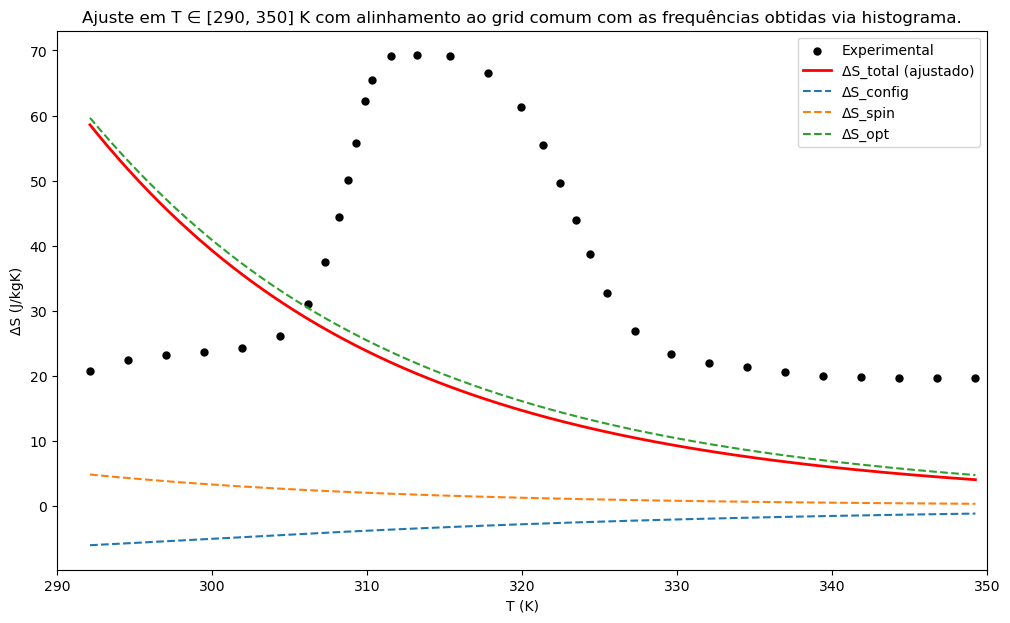

In [40]:
# Todas as frequencias foram utilizadas para o fit.
frequencias_HS = [20,20,20,20,20,20,20,20,20,20,20,20,20,20,20]
frequencias_LS = [74,74,74,74,74,74,74,74,74,74,74,74,74,74,74]
# Intervalo do ajuste
T_min = 290
T_max = 350
out = fit_params(T_exp, DS_exp,
                 to_fit=("g","Delta0","T0","deltaV"),  # parametros a serem fitados
                 init_guess={"T0":400,"g":864,"Delta0":3000,"deltaV":35e-30},
                 bounds={"T0":(50,650),"g":(500,20000),"Delta0":(1000,5000),"deltaV":(10e-30,90e-30)},
                 T_range=(T_min,T_max), n_points=None)

print("Parâmetros ajustados:", out["fitted_params"])

# Plot: ajuste total + componentes no grid comum
plt.figure(figsize=(12,7))
plt.scatter(data["T(K)"].values, data["DS(J/kgK)"].values, label="Experimental", s=25,color='black')
plt.plot(out["T_common"], out["DS_fit"],  label="ΔS_total (ajustado)", linewidth=2,color='red')
plt.plot(out["T_common"], out["DS_conf"], label="ΔS_config", ls="--")
plt.plot(out["T_common"], out["DS_spin"], label="ΔS_spin",  ls="--")
plt.plot(out["T_common"], out["DS_opt"],  label="ΔS_opt",   ls="--")
plt.xlabel("T (K)")
plt.ylabel("ΔS (J/kgK)")
plt.title(f"Ajuste em T ∈ [{T_min}, {T_max}] K com alinhamento ao grid comum com as frequências obtidas via histograma.")
plt.legend()
plt.xlim(290,350)
plt.show()